## Init

In [1]:
import numpy as np
import pandas as pd
import multiprocess as mp
import time
import sys
import matplotlib.pyplot as plt
import torch
import copy

from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.analysis_type import Classic
from pyrqa.neighbourhood import FixedRadius
from pyrqa.metric import EuclideanMetric
from pyrqa.computation import RQAComputation

pd.options.mode.copy_on_write = True

In [2]:
folder = "C:/Users/B00955739/Documents/Git/phd/Init/"

sys.path.append(folder)

import functions_v6_9 as fn
import ml_functions as mlf
import multiprocess_fn_v2 as mpfn

In [3]:
folder = "C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/"
csv = "main_run_v2_corrected.csv"

In [4]:
run_name = "modelling_run_v2"

In [5]:
full_df = pd.read_csv(folder + csv)

In [6]:
n_layers = 4
layer_size = 200
lr = 0.001
batch_size = 32
lr_decay_factor = 0.1
epoch_vals = [100]

reps = 3

## Sampling

Exclude systems that were run in modelling_run_v1

In [7]:
# model_csv1 = "modelling_run_v1.csv"
# model_csv2 = "modelling_run_v1_1d.csv"

In [8]:
# mod_df_1 = pd.read_csv(folder + model_csv1)
# mod_df_2 = pd.read_csv(folder + model_csv2)

# mod_df = pd.concat([mod_df_1, mod_df_2])

# prev_run_all = mod_df.system_id.unique()

# grouped_mod_df = mod_df.groupby(by='system_id', as_index=False).max()

# grouped_mod_df.head()
# already_run = pd.Series(grouped_mod_df[grouped_mod_df['pred_h_perfect_pred_count t=0.05'] == 0].system_id.unique(), name='system_id')
# needs_rerun = pd.Series(grouped_mod_df[grouped_mod_df['pred_h_perfect_pred_count t=0.05'] > 0].system_id.unique(), name='system_id')

# print("Already run: {} systems".format(len(already_run)))
# print("Needs rerun: {} systems".format(len(needs_rerun)))

Already run: 125 systems
Needs rerun: 16 systems


In [9]:
# mod_v1_noinf_name = "modelling_run_v1_noinf.csv"

# mod_v1_noinf = pd.merge(left=mod_df, right=already_run, how='inner', on=['system_id'])
# print(len(mod_v1_noinf))

375


In [10]:
# mod_v1_noinf.to_csv(folder+mod_v1_noinf_name)

Perform stratified sampling

In [11]:
# full_df_np = full_df[full_df.system_periodic == False].copy()

In [12]:
# full_df_np["embed_groupings"] = np.where(full_df_np.embed_success, full_df_np.embed_dim, 0)
# print(np.sort(full_df_np["embed_groupings"].unique()))

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18.]


In [13]:
# def lyap_group_fn(row):
#     if row['largest_lyap'] <= 0.05:
#         return 'quasiperiodic'
#     if row['largest_lyap'] > 0.05 and row['largest_lyap'] <= 0.4:
#         return 'low'
#     if row['largest_lyap'] > 0.4 and row['largest_lyap'] <= 0.8:
#         return 'medium'
#     if row['largest_lyap'] > 0.8:
#         return 'high'

# full_df_np["lyap_groupings"] = full_df_np.apply(lyap_group_fn, axis=1)
# print(full_df_np["lyap_groupings"].unique())

['quasiperiodic' 'low' 'high' 'medium']


In [14]:
# full_df_np.head()

,Unnamed: 0.1,Unnamed: 0,dim,mat_type,epsilon,map_list,map_list_str,gamma,reverse,matrix,...,lyap_5,lyap_6,lyap_7,lyap_8,lyap_9,largest_lyap,corrected,lyap_spectrum_full,embed_groupings,lyap_groupings
0,0,0,1,NN,0.1,[<functions_v6.sincircle_map object at 0x00000...,"[('sin_circle_map', {'omega': 1.41421356237309...",3.0,False,[[1.]],...,NaN,NaN,NaN,NaN,NaN,0.000016,False,"[1.5845574167039368e-05, nan, nan, nan, nan, n...",1.0,quasiperiodic
1,1,1,1,NN,0.1,[<functions_v6.sincircle_map object at 0x00000...,"[('sin_circle_map', {'omega': 0.5, 'k': 2})]",1.0,False,[[1.]],...,NaN,NaN,NaN,NaN,NaN,0.351925,False,"[0.3519253487725863, nan, nan, nan, nan, nan, ...",1.0,low
2,2,2,1,NN,0.1,[<functions_v6.tent_map object at 0x000002990D...,"[('tent_map', {'a': 1.9999999999, 'b': 27.2990...",3.0,False,[[1.]],...,NaN,NaN,NaN,NaN,NaN,4.000000,False,"[3.999999999950663, nan, nan, nan, nan, nan, n...",1.0,high
3,3,3,1,NN,0.1,[<functions_v6.tent_map object at 0x00000298DC...,"[('tent_map', {'a': 1.9999999999, 'b': 1})]",0.5,True,[[1.]],...,NaN,NaN,NaN,NaN,NaN,0.693147,False,"[0.6931471805096966, nan, nan, nan, nan, nan, ...",1.0,medium
4,4,4,1,NN,0.1,[<functions_v6.sluze_map object at 0x00000298E...,"[('sluze_map', {'m': 0.8, 'p': 0.2})]",0.5,True,[[1.]],...,NaN,NaN,NaN,NaN,NaN,0.417346,False,"[0.417345868882577, nan, nan, nan, nan, nan, n...",1.0,medium


In [15]:
# sample_1 = pd.merge(left=full_df_np, right=needs_rerun, how='inner', on=['system_id'])

In [16]:
# full_df_notrun = full_df_np[full_df_np.system_id.isin(prev_run_all) == False]

In [17]:
# samp_size = 15
# random_seed = 123

# sample_2 = full_df_notrun.groupby(['embed_groupings', 'lyap_groupings'], group_keys=False
#                                  )[full_df_notrun.columns.tolist()].apply(lambda x: x.sample(min(len(x), samp_size), random_state=random_seed))

In [18]:
# print(len(sample_1), len(sample_2))

16 858


In [19]:
# sample = pd.concat([sample_1, sample_2])
# print(len(sample))

874


In [20]:
# sample.reverse = sample.reverse.astype(int)

# sample.loc[sample.mat_type == "RAND", "epsilon"] = pd.NA
# sample.loc[sample.mat_type != "OW", "reverse"] = pd.NA
# sample.loc[sample.mat_type != "FCD", "gamma"] = pd.NA

In [21]:
# sample.sort_values(by='embed_dim', inplace=True)

# sample.head()

,Unnamed: 0.1,Unnamed: 0,dim,mat_type,epsilon,map_list,map_list_str,gamma,reverse,matrix,...,lyap_5,lyap_6,lyap_7,lyap_8,lyap_9,largest_lyap,corrected,lyap_spectrum_full,embed_groupings,lyap_groupings
0,0,0,1,NN,0.1,[<functions_v6.sincircle_map object at 0x00000...,"[('sin_circle_map', {'omega': 1.41421356237309...",NaN,NaN,[[1.]],...,NaN,NaN,NaN,NaN,NaN,0.000016,False,"[1.5845574167039368e-05, nan, nan, nan, nan, n...",1.0,quasiperiodic
210347,210347,210347,9,FC,0.7,[<functions_v6.sluze_map object at 0x0000029A7...,"[('sluze_map', {'m': 0.8, 'p': 0.2}), ('tent_m...",NaN,NaN,[[0.3 0.0875 0.0875 0.0875 0.0875 0.0875 0....,...,-1.201791,-1.360624,-1.451679,-1.549608,NaN,0.387591,False,"[0.3875914244041919, -0.8556733021597407, -0.8...",1.0,low
40027,40027,40027,6,FC,0.9,[<functions_v6.tent_map object at 0x000002994E...,"[('tent_map', {'a': 1.9999999999, 'b': 1}), ('...",NaN,NaN,[[0.1 0.18 0.18 0.18 0.18 0.18]\n [0.18 0.1 ...,...,-2.610067,NaN,NaN,NaN,NaN,0.197745,False,"[0.1977452155405668, -1.8325835866582791, -1.8...",1.0,low
210612,210612,210612,9,FC,0.7,[<functions_v6.tent_map object at 0x0000029A7C...,"[('tent_map', {'a': 1.9999999999, 'b': 1}), ('...",NaN,NaN,[[0.3 0.0875 0.0875 0.0875 0.0875 0.0875 0....,...,-1.344706,-1.406632,-1.553537,-1.553544,NaN,0.221796,False,"[0.221796221502067, -0.8556487814284155, -1.01...",1.0,low
26062,26062,26062,6,FC,0.3,[<functions_v6.sincircle_map object at 0x00000...,"[('sin_circle_map', {'omega': 0.5, 'k': 2}), (...",NaN,NaN,[[0.7 0.06 0.06 0.06 0.06 0.06]\n [0.06 0.7 ...,...,-0.173915,NaN,NaN,NaN,NaN,0.250457,False,"[0.2504571123863089, -0.1294240210744437, -0.1...",1.0,low


In [22]:
# all_res = []

# for i in range(10):
#     print(i)
#     pool = mp.Pool()
#     results = [pool.apply_async(test_fn, args=(x,)) for x in inp_list]
#     pool.close()
#     pool.join()
#     result_list = [result.get() for result in results]
#     pool.terminate()
#     pool.join()
#     all_res.append(result_list)

## Calculate Extra Metrics

In [23]:
# sample['n_layers'] = [n_layers] * len(sample)
# sample['layer_size'] = [layer_size] * len(sample)
# sample['lr'] = [lr] * len(sample)
# sample['batch_size'] = [batch_size] * len(sample)
# sample['lr_decay_factor'] = [lr_decay_factor] * len(sample)
# sample['epoch_vals'] = [epoch_vals] * len(sample)

In [24]:
# start_time = time.time()

# updated_list = []

# for sys_dict in sample.to_dict('records'):
#     sys_dict['embed_dim'] = int(sys_dict['embed_dim'])
#     out_dict = sys_dict.copy()

#     sim = np.load(sys_dict['sim_file'])
    
#     corrected_LDDP, corrected_LDDP_err = fn.calc_LDDP_corrected(sim)
    
#     rqa_ts = TimeSeries(sim, embedding_dimension=sys_dict['embed_dim'], time_delay=1)
    
#     settings = Settings(rqa_ts)
#     computation = RQAComputation.create(settings, verbose=False)
#     result = computation.run()
#     rqa_rr = result.recurrence_rate
#     rqa_det = result.determinism
    
#     assert len(sim) == sys_dict['modelling_len'] + sys_dict['testing_len']
#     modelling_series = sim[:sys_dict['modelling_len']]
#     testing_series = sim[-sys_dict['testing_len']:]
    
#     modelling_range = np.max(modelling_series) - np.min(modelling_series)
#     sim_range = np.max(sim) - np.min(sim)

#     out_dict['modelling_range'] = modelling_range
#     out_dict['sim_range'] = sim_range
#     out_dict['corrected_LDDP'] = corrected_LDDP
#     out_dict['corrected_LDDP_err'] = corrected_LDDP_err
#     out_dict['RQA_rr'] = rqa_rr
#     out_dict['RQA_det'] = rqa_det

#     updated_list.append(out_dict)

# updated_sample = pd.DataFrame(updated_list)

# end_time = time.time()
# metric_time_nmp = end_time - start_time

In [25]:
# print("Metric update time: {} mins".format(round(metric_time_nmp/60, 2)))

Metric update time: 63.51 mins


In [26]:
# updated_sample.to_csv(folder+run_name+"_metric_update.csv")

In [7]:
updated_sample = pd.read_csv(folder+run_name+"_metric_update.csv")

In [8]:
rep_df = pd.DataFrame({'rep_id': np.arange(0, reps)})

sample_rep = updated_sample.merge(rep_df, how='cross')
sample_rep.sort_values(by='embed_dim', inplace=True)

sample_rep['epoch_vals'] = [[100]] * len(sample_rep)

sample_list = sample_rep.to_dict('records')

C:\Users\B00955739\AppData\Local\Temp\ipykernel_2472\3336811587.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_rep = updated_sample.merge(rep_df, how='cross')


In [10]:
print(sample_rep['epoch_vals'])
print(sample_rep['epoch_vals'][0])
print(sample_rep['epoch_vals'][0][0])

0       [100]
121     [100]
122     [100]
123     [100]
124     [100]
        ...  
2564    [100]
2563    [100]
2562    [100]
2560    [100]
2621    [100]
Name: epoch_vals, Length: 2622, dtype: object
[100]
100


In [11]:
sample_rep.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,dim,mat_type,epsilon,map_list,map_list_str,gamma,reverse,...,batch_size,lr_decay_factor,epoch_vals,modelling_range,sim_range,corrected_LDDP,corrected_LDDP_err,RQA_rr,RQA_det,rep_id
0,0,0,0,1,NN,0.1,[<functions_v6.sincircle_map object at 0x00000...,"[('sin_circle_map', {'omega': 1.41421356237309...",NaN,NaN,...,32,0.1,[100],0.999957,0.999957,-0.117951,0.0,1.0,1.0,0
121,40,36666,36666,6,RAND,NaN,[<functions_v6.sincircle_map object at 0x00000...,"[('sin_circle_map', {'omega': 0.5, 'k': 2}), (...",NaN,NaN,...,32,0.1,[100],0.546924,0.546926,-3.074630,0.0,1.0,1.0,1
122,40,36666,36666,6,RAND,NaN,[<functions_v6.sincircle_map object at 0x00000...,"[('sin_circle_map', {'omega': 0.5, 'k': 2}), (...",NaN,NaN,...,32,0.1,[100],0.546924,0.546926,-3.074630,0.0,1.0,1.0,2
123,41,39828,39828,6,NN,0.9,[<functions_v6.log_map object at 0x000002994DF...,"[('log_map', {'a': 4}), ('log_map', {'a': 4}),...",NaN,NaN,...,32,0.1,[100],0.167861,0.167861,-1.905024,0.0,1.0,1.0,0
124,41,39828,39828,6,NN,0.9,[<functions_v6.log_map object at 0x000002994DF...,"[('log_map', {'a': 4}), ('log_map', {'a': 4}),...",NaN,NaN,...,32,0.1,[100],0.167861,0.167861,-1.905024,0.0,1.0,1.0,1


In [12]:
cont_vars = [
    'prop_pos_lyap',
    'ky_dim',
    'ks_ent',
    'largest_lyap',
    'hurst',
    'fisher',
    'svd',
    'skewness',
    'skew_test_p',
    'kurtosis',
    'kurt_test_p',
    'series_mean',
    'series_std',
    'coefficient_variation',
    'dfa',
    'differential_entropy',
    'lddp',
    'knn_max_abs_err',
    'knn_med_abs_err',
    'knn_mae',
    'knn_R_squared',
    'knn_delta_min',
    'knn_delta_max',
    'knn_delta_mean',
    'knn_series_initial_delta_min',
    'knn_series_initial_delta_max',
    'knn_series_initial_delta_mean',
    'knn_series_mae',
    'knn_pred_h_mean t=0.001',
    'knn_pred_h_mean t=0.01',
    'knn_pred_h_mean t=0.05',
]

discrete_vars = [
    'dim',
    'mat_type',
    'epsilon',
    'gamma',
    'reverse',
    'analysis_dim',
    'n_unique_maps',
    'chaotic',
    'hyperchaotic',
    'n_pos_lyap',
    'system_periodic',
    'embed_dim',
    'embed_success',
    'series_periodic',
]

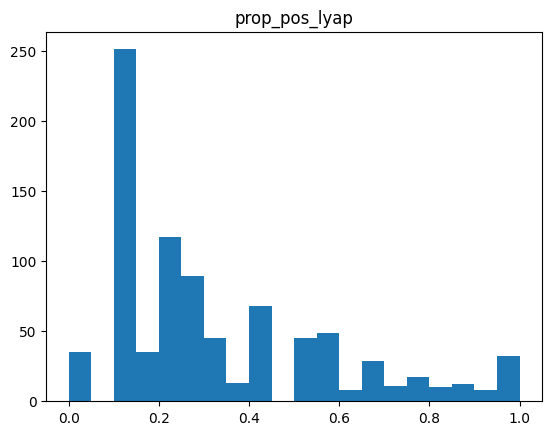

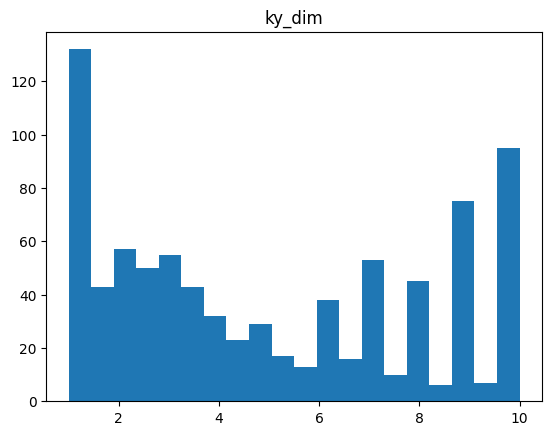

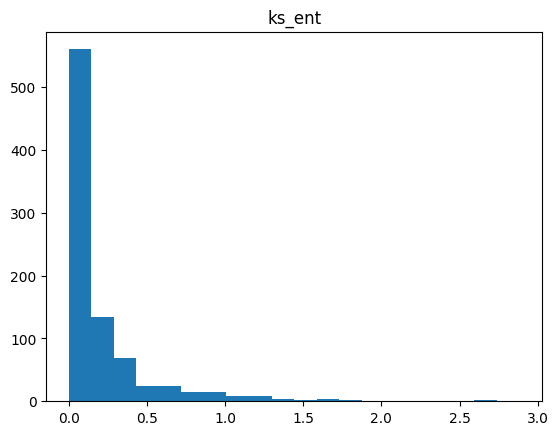

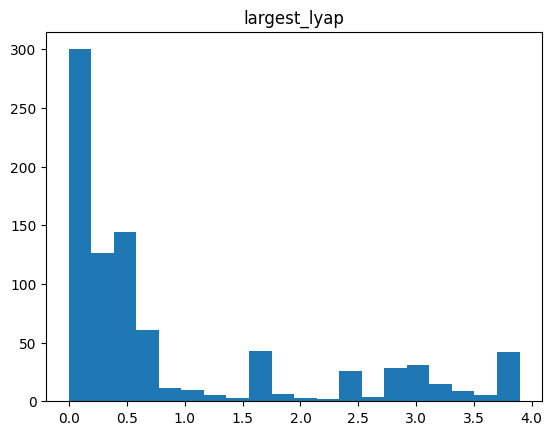

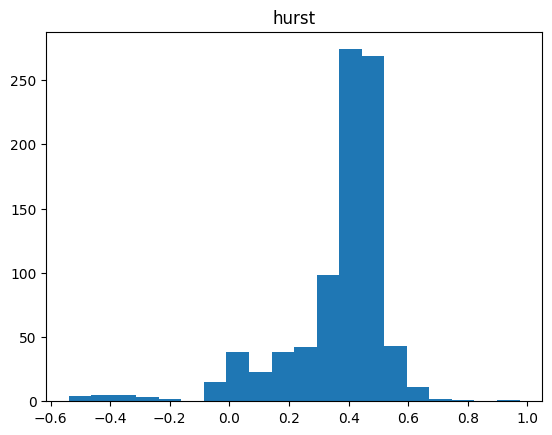

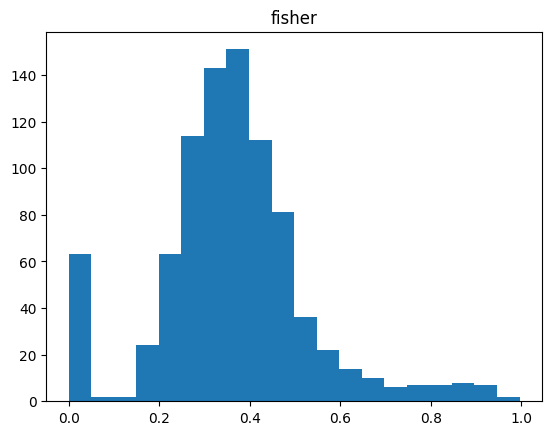

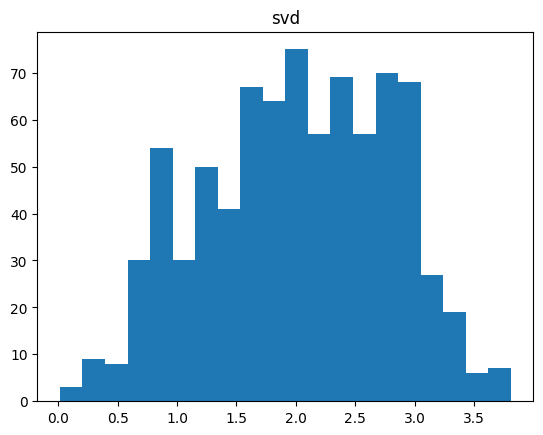

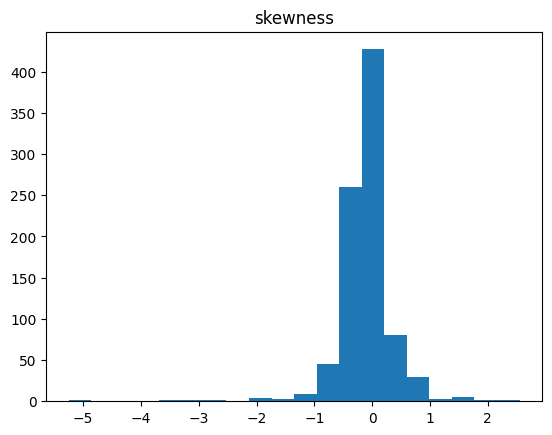

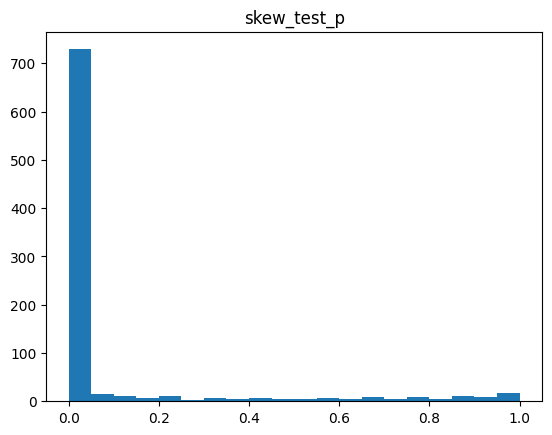

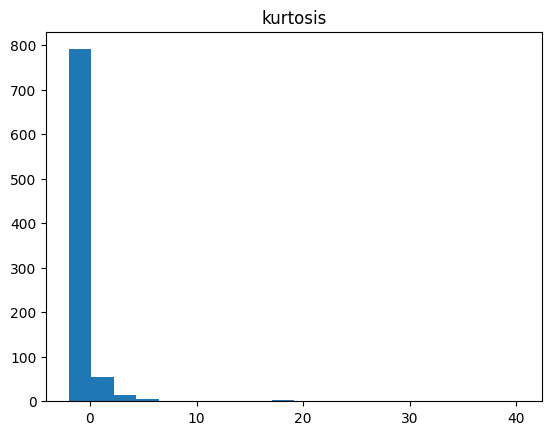

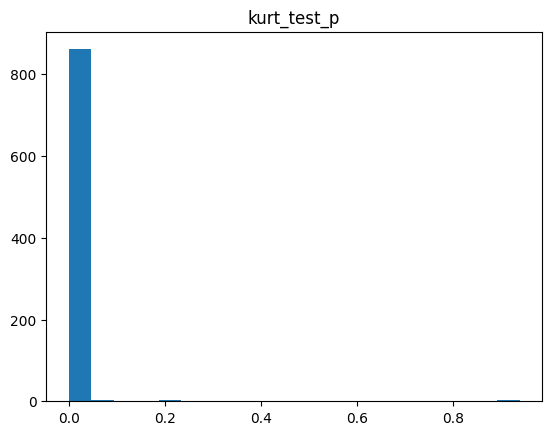

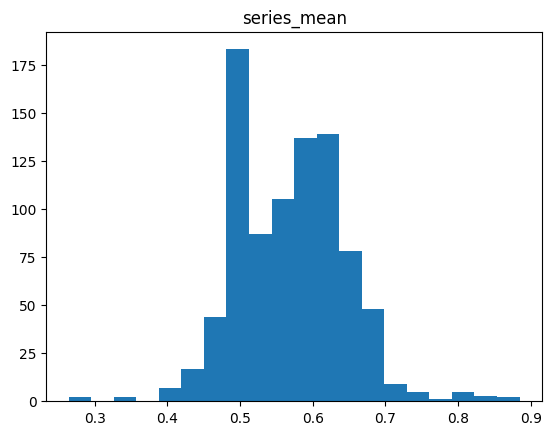

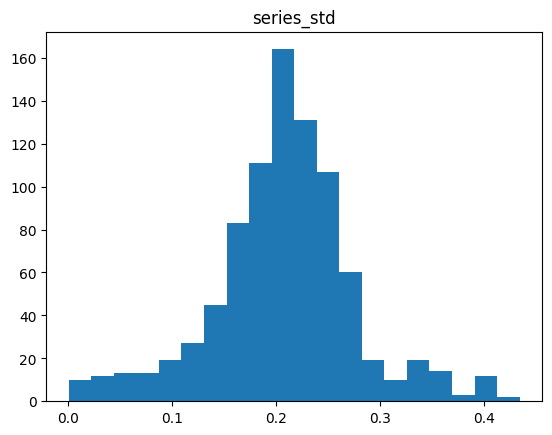

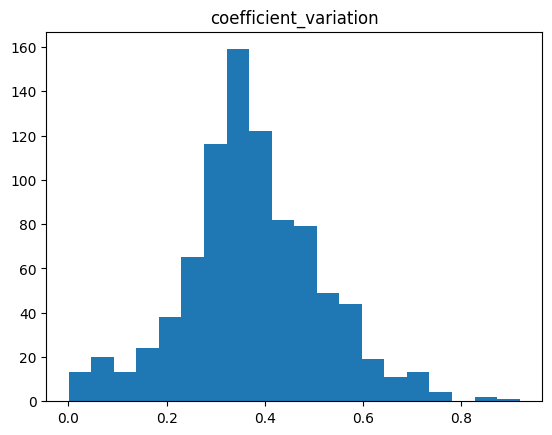

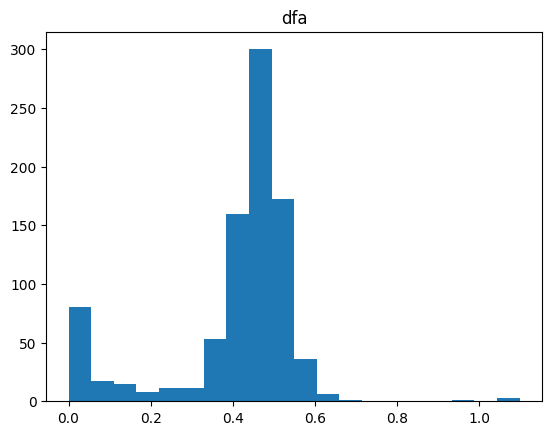

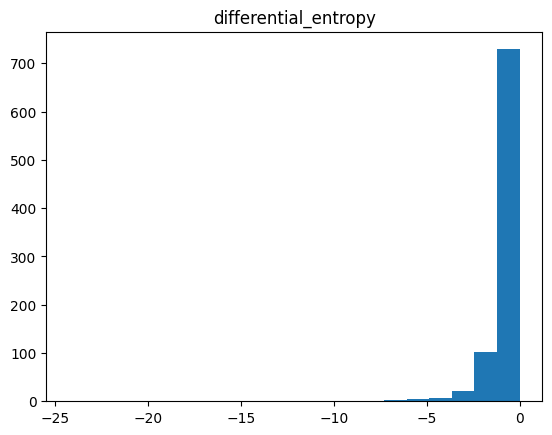

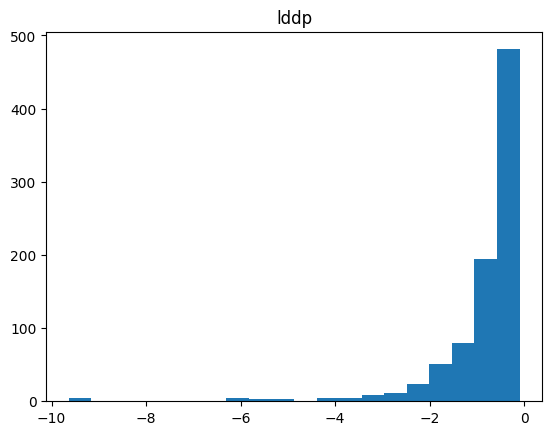

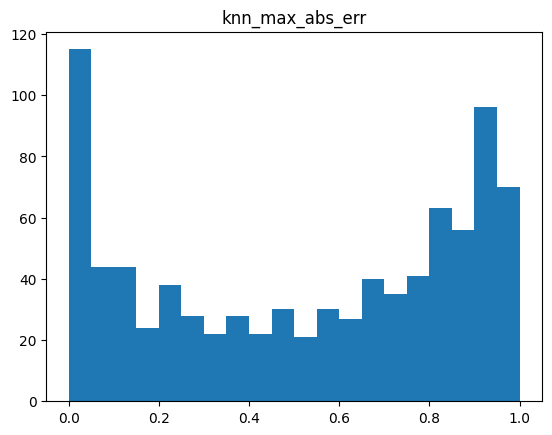

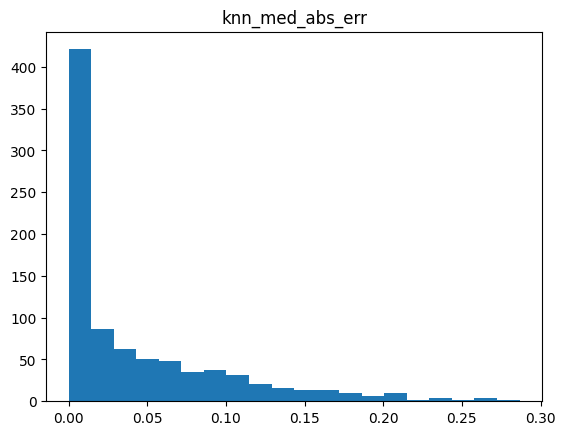

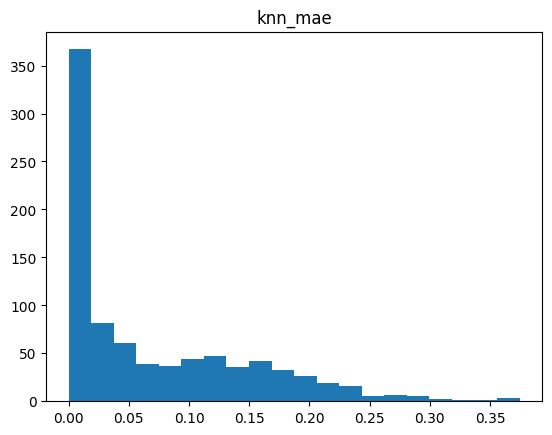

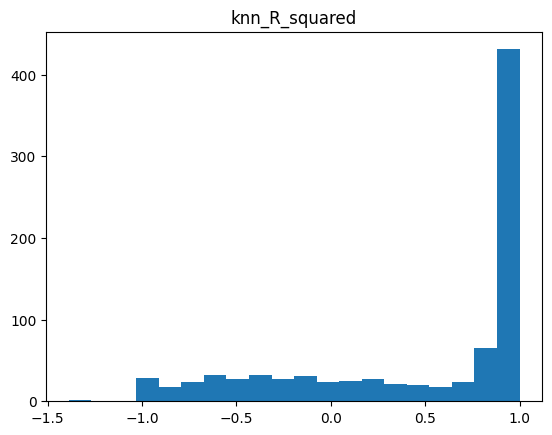

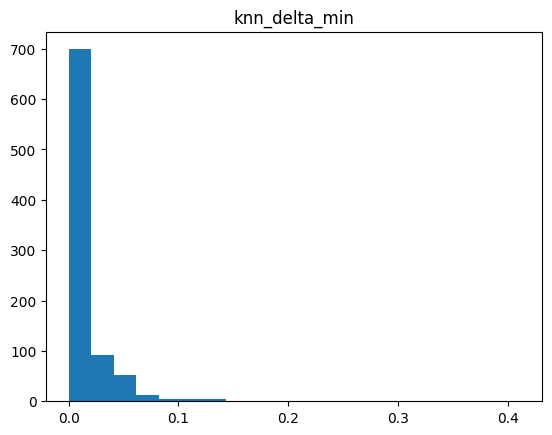

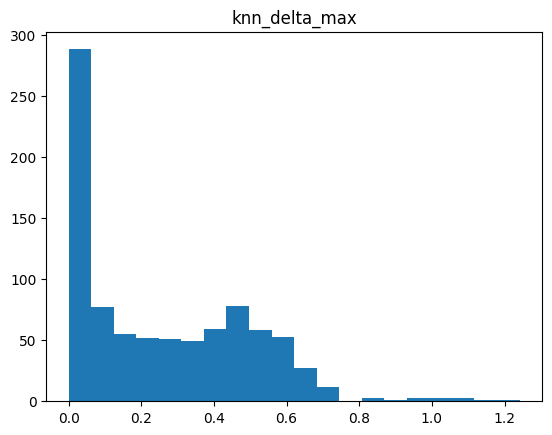

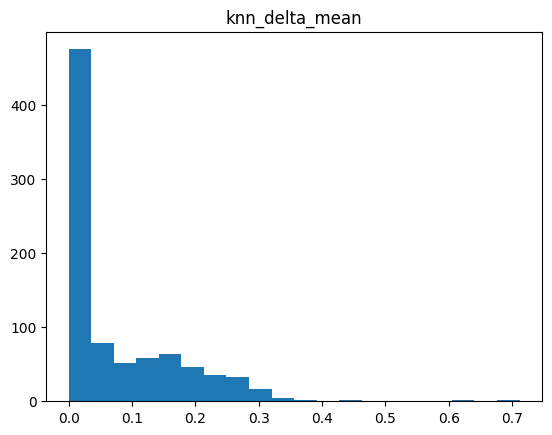

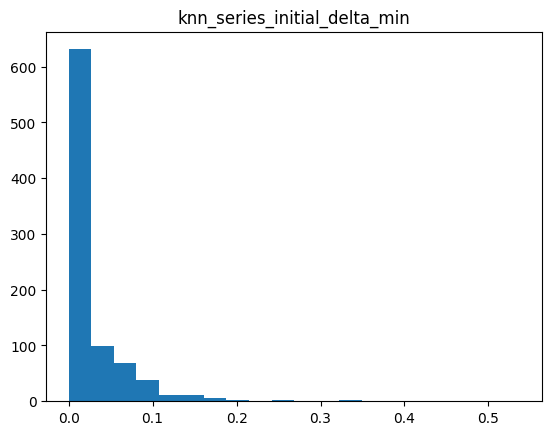

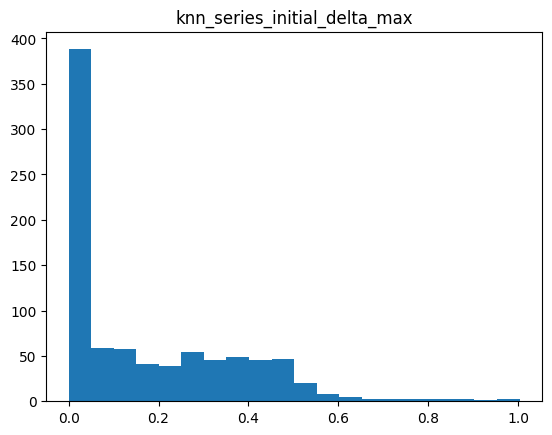

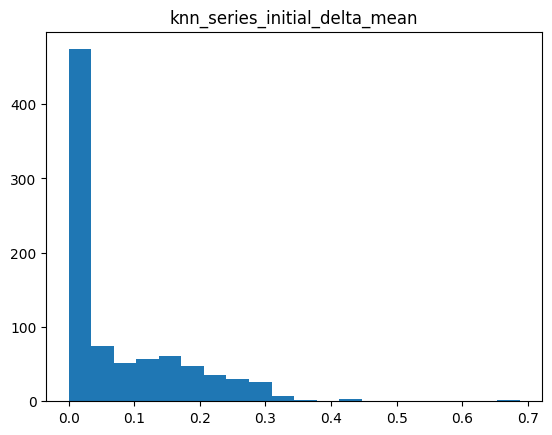

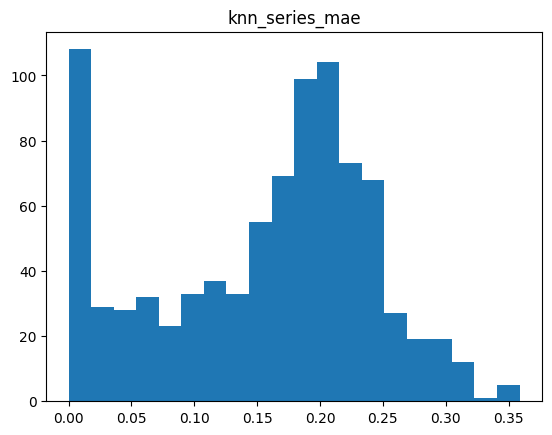

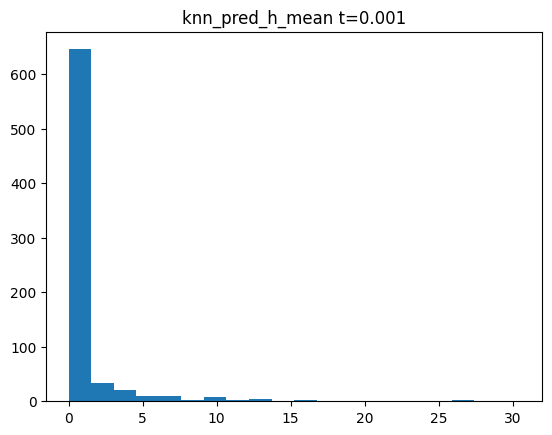

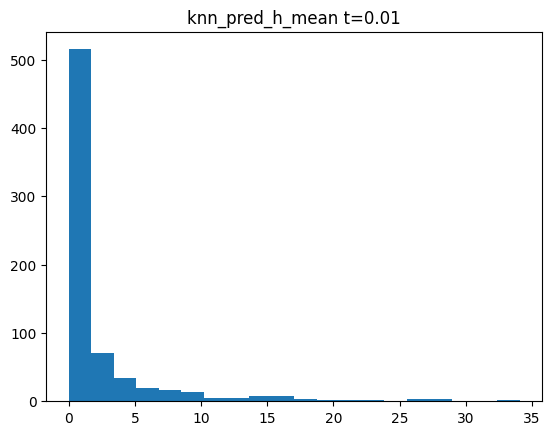

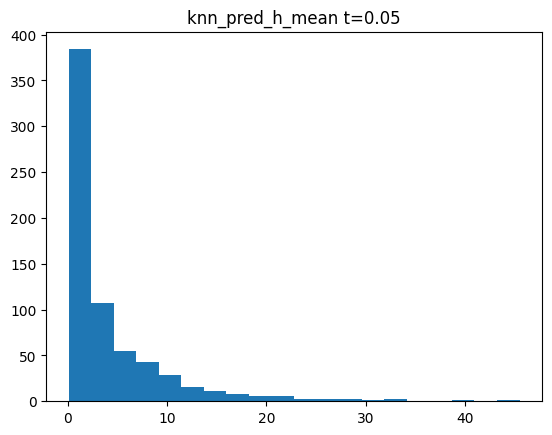

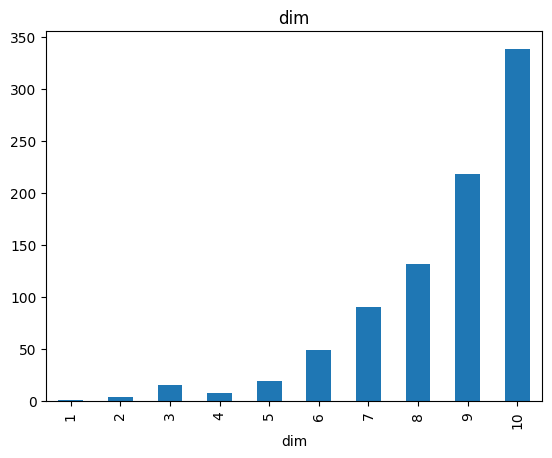

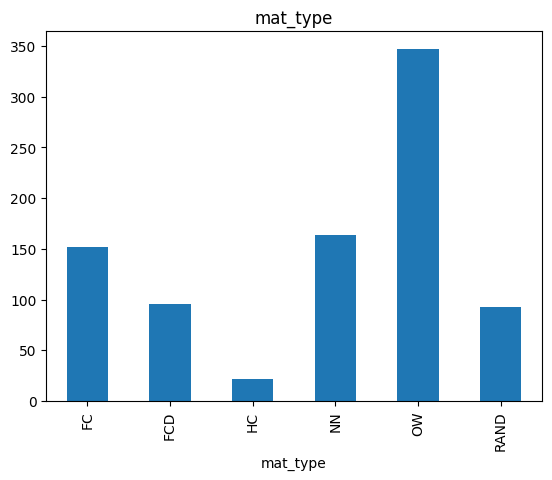

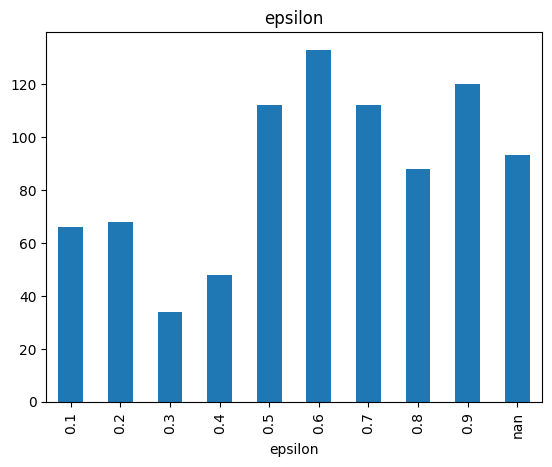

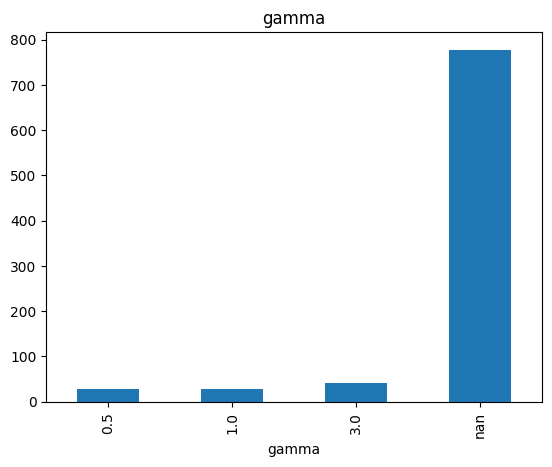

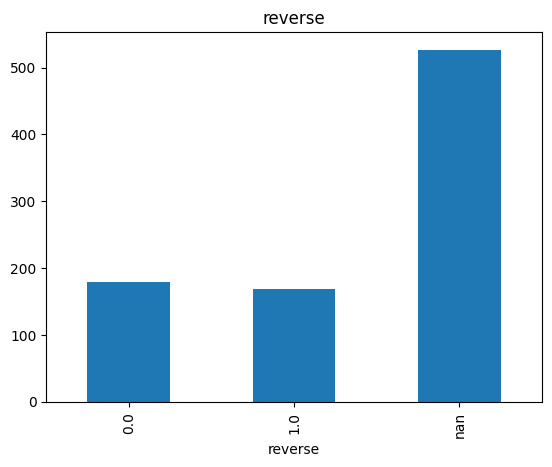

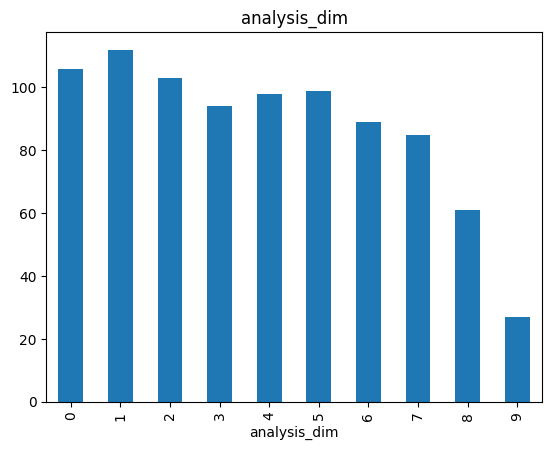

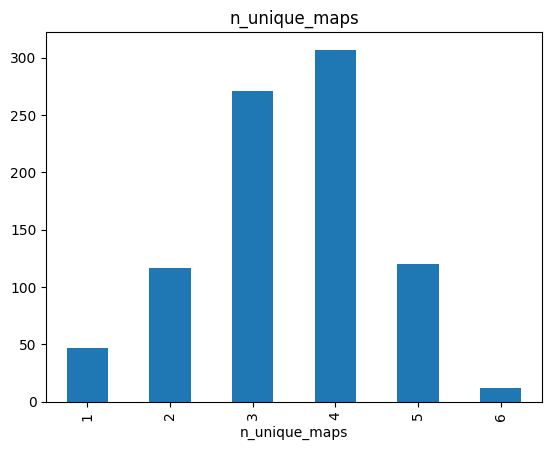

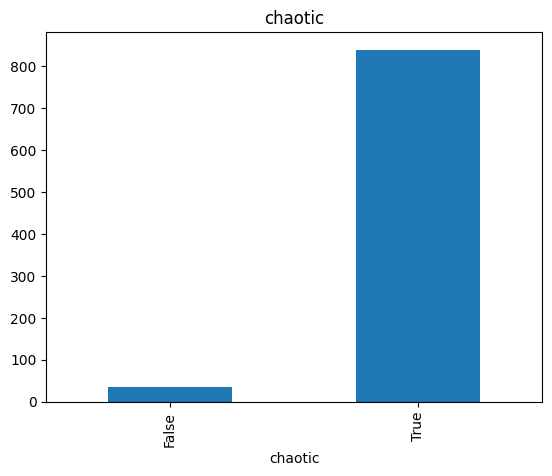

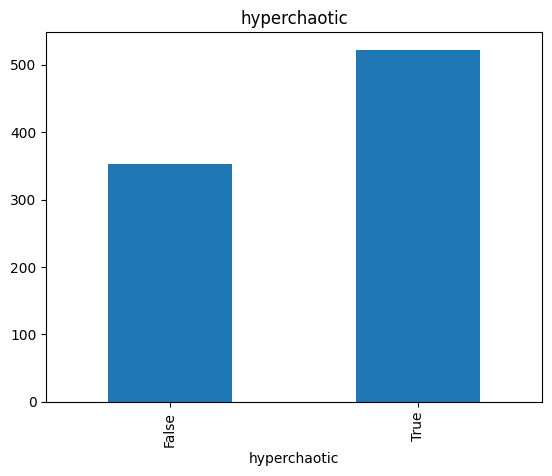

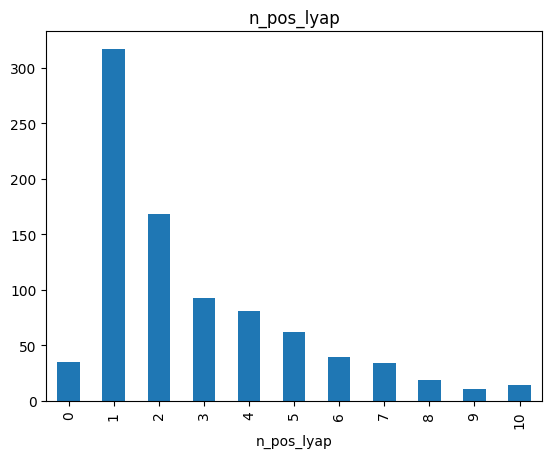

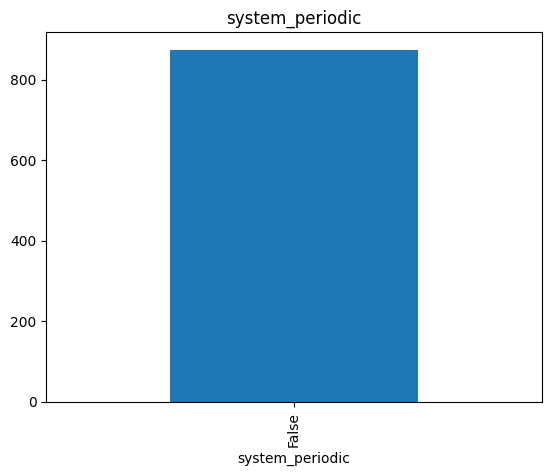

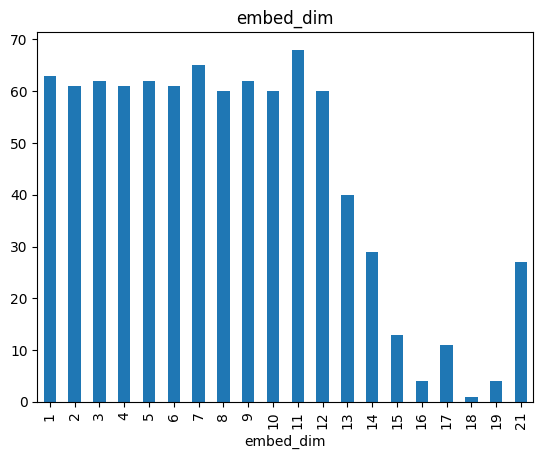

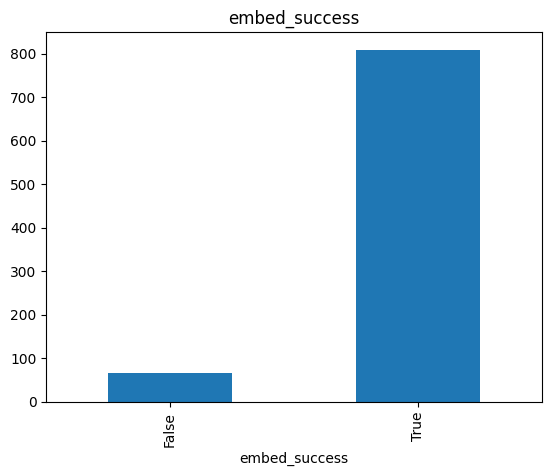

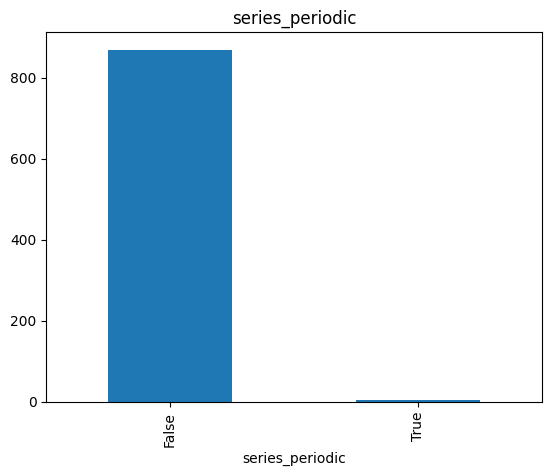

In [13]:
for m in cont_vars:
    arr = updated_sample[m].replace([np.inf, -np.inf], np.nan).dropna()
    
    plt.figure()
    plt.hist(arr, bins=20)
    plt.title(m)
    plt.show()
    plt.close()

for m in discrete_vars:
    plt.figure()
    updated_sample.groupby([m], dropna=False).size().plot(kind='bar')
    plt.title(m)
    plt.show()
    plt.close()

## Modelling

In [14]:
model_count = len(sample_list)

print("{} models to train ({} systems; {} reps)".format(model_count, int(model_count/reps), reps))

2622 models to train (874 systems; 3 reps)


In [15]:
print(mp.cpu_count())
cpu_count = mp.cpu_count()

24


In [16]:
split_values = np.unique(np.arange(0, model_count, 2*cpu_count, dtype=int))
split_values = np.insert(split_values, 1, model_count)
split_values.sort()

print(split_values)

[   0   48   96  144  192  240  288  336  384  432  480  528  576  624
  672  720  768  816  864  912  960 1008 1056 1104 1152 1200 1248 1296
 1344 1392 1440 1488 1536 1584 1632 1680 1728 1776 1824 1872 1920 1968
 2016 2064 2112 2160 2208 2256 2304 2352 2400 2448 2496 2544 2592 2622]


In [17]:
print(len(split_values))

56


In [19]:
for i in range(36, len(split_values)-1):
    print(i)
    start_index=split_values[i]
    end_index=split_values[i+1]
    print(start_index, end_index)

36
1728 1776
37
1776 1824
38
1824 1872
39
1872 1920
40
1920 1968
41
1968 2016
42
2016 2064
43
2064 2112
44
2112 2160
45
2160 2208
46
2208 2256
47
2256 2304
48
2304 2352
49
2352 2400
50
2400 2448
51
2448 2496
52
2496 2544
53
2544 2592
54
2592 2622


In [22]:
# print(sample_list[2621])
# # print(sample_list[2622])

In [ ]:
start_index=0
end_index=3
pool = mp.Pool(len(sample_list[start_index:end_index]))
results = [pool.apply_async(mpfn.model_system, args=(s_d,)) for s_d in sample_list[start_index:end_index]]
pool.close()
pool.join()
result_list = [result.get() for result in results]

out_df = pd.DataFrame(result_list)

out_df.head()

In [ ]:
start_time = time.time()
all_out_dfs = []

for i in range(36, len(split_values)-1):
    start_index=split_values[i]
    end_index=split_values[i+1]
    pool = mp.Pool()
    results = [pool.apply_async(mpfn.model_system, args=(s_d,)) for s_d in sample_list[start_index:end_index]]
    pool.close()
    pool.join()
    result_list = [result.get() for result in results]
    
    out_df = pd.DataFrame(result_list)

    print("Saving interim csv: {}".format(folder+run_name+"_part{}.csv".format(int(i))))
    out_df.to_csv(folder+run_name+"_part{}.csv".format(int(i)))
    
    all_out_dfs.append(out_df)

end_time = time.time()
full_time = end_time - start_time

In [ ]:
time_hrs = round(full_time/(60*60), 2)

print("Multiprocessing time taken: {} hours".format(time_hrs))

In [ ]:
# final_out_df = pd.concat(all_out_dfs)

In [ ]:
# print("Saving final csv: {}".format(folder+run_name+".csv"))

# final_out_df.to_csv(folder+run_name+".csv")

In [ ]:
# final_out_df.head()